In [170]:
import math

import numpy as np

import pandas as pd
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

import datetime as dt

from scipy.stats.stats import pearsonr

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.linear_model import LinearRegression

### Importing and Cleaning Market Data

In [171]:
#Importing Market Data
df_md = pd.read_csv('marketData.csv') 

# Fixing the Date Column
str(df_md['Date'].iloc[0])[0:4] + '-' + str(df_md['Date'].iloc[0])[4:6] + '-' + str(df_md['Date'].iloc[0])[6:8]
list = []
for n in range (0, len(df_md['Date'])):
    list.append(str(df_md['Date'].iloc[n])[0:4] + '-' + str(df_md['Date'].iloc[n])[4:6] + '-' + str(df_md['Date'].iloc[n])[6:8])
df_md['Date'] = list
df_md.index = df_md['Date']

### Importing and Cleaning Sentiment Data

In [172]:
# Importing Sentiment Data
df_sent = pd.read_csv('sentimentData.csv', dtype = {})

# Fixing TIMESTAMP Column
df_sent = df_sent[['TIMESTAMP', 'STOCK','RELEVANCE', 'SENT_POS', 'SENT_NEUT', 'SENT_NEG']]
list2 = []
for n in range (0, len(df_sent['TIMESTAMP'])):
    list2.append(str(df_sent['TIMESTAMP'].iloc[n])[0:10])
df_sent['TIMESTAMP'] = list2
df_sent.index = df_sent['TIMESTAMP']
df_sent = df_sent[['STOCK','RELEVANCE', 'SENT_POS', 'SENT_NEUT', 'SENT_NEG']]

D:\PRogramas\Anaconda\lib\site-packages\IPython\core\interactiveshell.py:3165: DtypeWarning: Columns (8,9,10) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


### Função Separar Ativo

In [173]:
def separar_ativo_md(ativo):
    df_md_ativo = df_md[['Date', 'SP500', ativo]]
    df_md_ativo.index = df_md_ativo['Date']
    df_md_ativo = df_md_ativo[['SP500', ativo]]
    return df_md_ativo

def separar_ativo_st(ativo):
    df_st_ativo = df_sent[df_sent['STOCK'] == 'WMT']
    return df_st_ativo

### Função join sentiment e market data pergunta 1

In [174]:
def join_st_md_p1(ativo):
    #Grouping Timestamp by first
    df_st_ativo_group = df_st_ativo[df_st_ativo['RELEVANCE'] == 1].groupby('TIMESTAMP').first()
    
    # Join
    df_join_ativo = df_md_ativo.join(df_st_ativo_group, how = 'inner')
    
    return df_join_ativo

### Função join sentiment e market data pergunta 2

In [175]:
def join_st_md_p2(ativo):
    # Grouping Timestamp by avg
    df_st_ativo_group = df_st_ativo.groupby('TIMESTAMP').mean()

    # Join
    df_join_ativo = df_md_ativo.join(df_st_ativo_group, how = 'inner')
    
    return df_join_ativo


# 1 - Utilizar alguma lógica para gerar séries de sentimento agregado para cada ativo, com a mesma frequëncia temporal das séries de preços. Para cada notícia individual, vocë pode combinar as probabilidades para criar um score único e opcionalmente utilizar a releväncia.

In [176]:
# Vou utilizar o primeiro com relevancia maxima

In [177]:
def return_df_max_relevance_first(ativo):
    
    # Separando Ativos
    df_md_ativo = separar_ativo_md(ativo)
    df_st_ativo = separar_ativo_md(ativo)
    
    # Joining sentiment and market data
    df_join_ativo = join_st_md_p1(ativo)
    
    return df_join_ativo

In [178]:
return_df_max_relevance_first('WMT')

,SP500,WMT,STOCK,RELEVANCE,SENT_POS,SENT_NEUT,SENT_NEG
2007-01-03,1416.60,47.55,WMT,1.0,0.235804,0.616898,0.147298
2007-01-04,1418.34,47.78,WMT,1.0,0.106241,0.227349,0.666409
2007-01-05,1409.71,47.39,WMT,1.0,0.338696,0.386023,0.275282
2007-01-08,1412.84,47.00,WMT,1.0,0.749907,0.154415,0.095678
2007-01-10,1414.85,47.28,WMT,1.0,0.397756,0.395026,0.207218
...,...,...,...,...,...,...,...
2009-12-22,1118.02,53.34,WMT,1.0,0.192836,0.112387,0.694777
2009-12-23,1120.59,53.32,WMT,1.0,0.805745,0.137721,0.056533
2009-12-24,1126.48,53.60,WMT,1.0,0.059315,0.924506,0.016178
2009-12-29,1126.20,54.11,WMT,1.0,0.059315,0.924506,0.016178


# 2 - Plotar gráﬁcos comparando a média móvel dos sentimentos diários de cada ativo com as respectivas séries de preços.

In [179]:
def plot(ativo):
    
    # Separando Ativos
    df_md_ativo = separar_ativo_md(ativo)
    df_st_ativo = separar_ativo_md(ativo)
    
    # Joining sentiment and market data
    df_join_ativo = join_st_md_p2(ativo)
    
    x = df_join_ativo.index
    y = df_join_ativo['WMT']
    z = df_join_ativo['SENT_POS']


    plt.plot(x,y, z)
    plt.show()

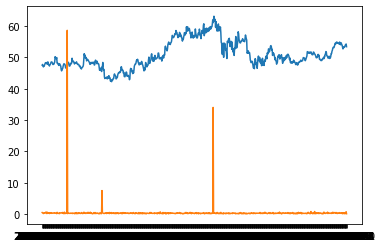

In [180]:
plot('WMT')

# Questão alternativa - Classificar o dia como predominantemente positivo (1) ou predominantemente negativo (0) entre todos os ativos no dia.

# Comparar com mudanca em sp500

In [181]:
df_sent_avg = df_sent.groupby('TIMESTAMP').mean()

df_sent_avg

,RELEVANCE,SENT_POS,SENT_NEUT,SENT_NEG
TIMESTAMP,,,,
2007-01-01,0.252703,0.270392,0.285666,0.443942
2007-01-02,0.469523,0.362221,0.368254,0.269524
2007-01-03,0.512330,0.320535,0.333332,0.346133
2007-01-04,0.612868,0.358787,2.560879,0.282078
2007-01-05,2.719590,0.270055,0.336345,0.393600
...,...,...,...,...
2009-12-27,0.201178,0.316441,0.372328,0.311231
2009-12-28,0.595849,0.306432,0.430053,0.263515
2009-12-29,0.565828,0.278343,0.364407,0.357251


In [182]:
list = []
for index, row in df_sent_avg.iterrows():
    (row['SENT_POS'] - row['SENT_NEG'])
    if row['SENT_POS'] > row['SENT_NEG']:
        list.append(1)
    if row['SENT_POS'] < row['SENT_NEG']:
        list.append(0)
    if row['SENT_POS'] == row['SENT_NEG']:
        list.append(1)

df_sent_avg['POS_or_NEG'] = list

In [183]:
df_sent_avg

,RELEVANCE,SENT_POS,SENT_NEUT,SENT_NEG,POS_or_NEG
TIMESTAMP,,,,,
2007-01-01,0.252703,0.270392,0.285666,0.443942,0
2007-01-02,0.469523,0.362221,0.368254,0.269524,1
2007-01-03,0.512330,0.320535,0.333332,0.346133,0
2007-01-04,0.612868,0.358787,2.560879,0.282078,1
2007-01-05,2.719590,0.270055,0.336345,0.393600,0
...,...,...,...,...,...
2009-12-27,0.201178,0.316441,0.372328,0.311231,1
2009-12-28,0.595849,0.306432,0.430053,0.263515,1
2009-12-29,0.565828,0.278343,0.364407,0.357251,0


In [184]:
df_md_sp500 = df_md[['SP500']]

df_md_sp500

,SP500
Date,
2007-01-03,1416.60
2007-01-04,1418.34
2007-01-05,1409.71
2007-01-08,1412.84
2007-01-09,1412.11
...,...
2009-12-24,1126.48
2009-12-28,1127.78
2009-12-29,1126.20


In [185]:
# Joining Both

df_join_sp500 = df_md_sp500.join(df_sent_avg, how = 'inner')

df_join_sp500

,SP500,RELEVANCE,SENT_POS,SENT_NEUT,SENT_NEG,POS_or_NEG
2007-01-03,1416.60,0.512330,0.320535,0.333332,0.346133,0
2007-01-04,1418.34,0.612868,0.358787,2.560879,0.282078,1
2007-01-05,1409.71,2.719590,0.270055,0.336345,0.393600,0
2007-01-08,1412.84,0.620669,0.351806,0.327986,0.320208,1
2007-01-09,1412.11,0.549139,0.357348,0.292675,0.349978,1
...,...,...,...,...,...,...
2009-12-24,1126.48,0.475268,0.229480,0.408897,0.361623,0
2009-12-28,1127.78,0.595849,0.306432,0.430053,0.263515,1
2009-12-29,1126.20,0.565828,0.278343,0.364407,0.357251,0
2009-12-30,1126.42,0.592609,0.294382,0.514301,0.191317,1


### I'll create a column that represents sp500 change between day and day-1

In [186]:
len(df_join_sp500)

756

In [187]:
df_join_sp500['delta'] = df_join_sp500['SP500'].diff()

In [188]:
df_join_sp500

,SP500,RELEVANCE,SENT_POS,SENT_NEUT,SENT_NEG,POS_or_NEG,delta
2007-01-03,1416.60,0.512330,0.320535,0.333332,0.346133,0,NaN
2007-01-04,1418.34,0.612868,0.358787,2.560879,0.282078,1,1.74
2007-01-05,1409.71,2.719590,0.270055,0.336345,0.393600,0,-8.63
2007-01-08,1412.84,0.620669,0.351806,0.327986,0.320208,1,3.13
2007-01-09,1412.11,0.549139,0.357348,0.292675,0.349978,1,-0.73
...,...,...,...,...,...,...,...
2009-12-24,1126.48,0.475268,0.229480,0.408897,0.361623,0,5.89
2009-12-28,1127.78,0.595849,0.306432,0.430053,0.263515,1,1.30
2009-12-29,1126.20,0.565828,0.278343,0.364407,0.357251,0,-1.58
2009-12-30,1126.42,0.592609,0.294382,0.514301,0.191317,1,0.22


In [190]:
df_corr = df_join_sp500[['POS_or_NEG', 'delta']]

df_corr.corr(method='pearson')

,POS_or_NEG,delta
POS_or_NEG,1.000000,0.185101
delta,0.185101,1.000000


Para a Pergunta 2 eu criei duas tabelas:
 
 abc: date_abc, close_abc 
 
 xyz: date_xyz, close_xyz

O commando que utilizei no MySQL para carregar os dados conforme a pergunta foi:


Select DATE_ABC, CLOSE_XYZ from abc

left join xyz

	on xyz.DATE_XYZ = abc.DATE_ABC